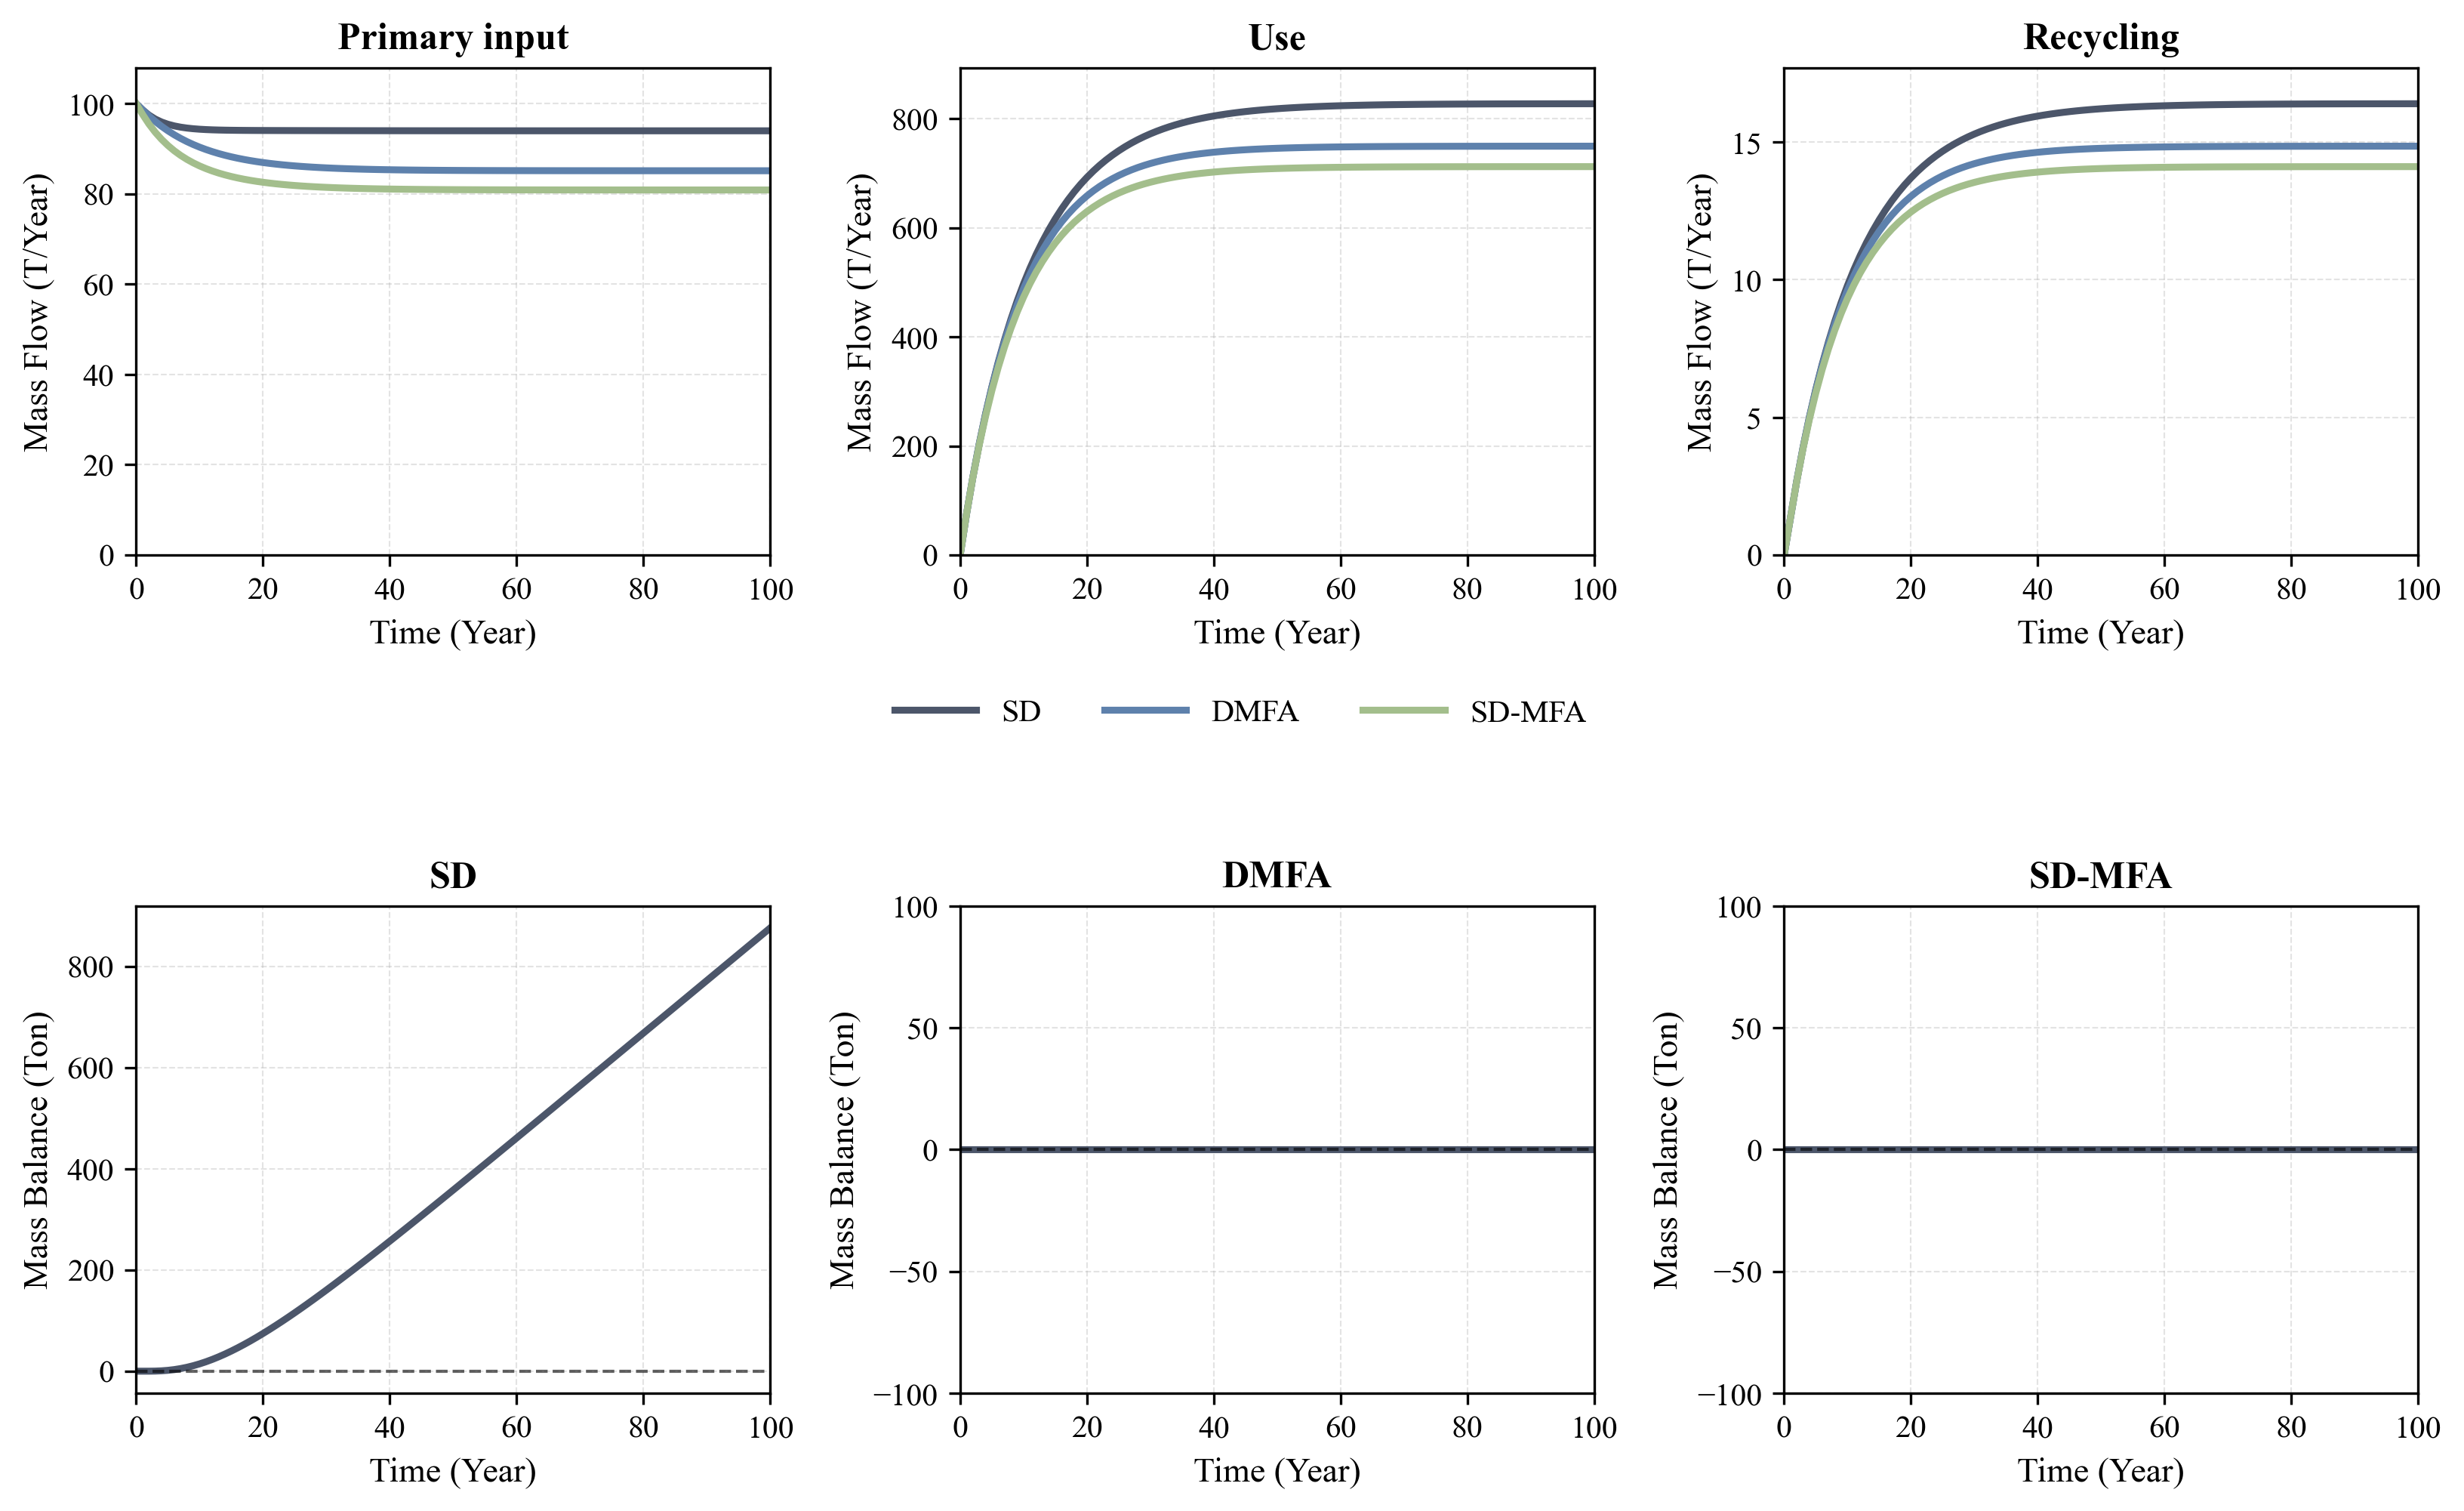

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from pathlib import Path

# ============================================================
# INPUT FILES
# ============================================================
comparison_file = Path("SD-MFA Comparison updated.xlsx")
mass_balance_file = Path("Mass Balance update.xlsx")


# ============================================================
# GLOBAL STYLE SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "figure.dpi": 300,
})

colors = {
    "SD": "#4C566A",
    "DMFA": "#5E81AC",
    "MFA": "#5E81AC",       # IF mistakenly writen as MFA, show as DMFA
    "SDMFA": "#A3BE8C",
    "SD-MFA": "#A3BE8C",
    "Mass Balance": "#4C566A",
}

line_width = 2.2

# ============================================================
# MASS BALANCE Y-LIMIT SETTINGS
# ============================================================

mass_balance_ylim = {
    "SD": None,
    "DMFA": (-100, 100),
    "SD-MFA": (-100, 100),
}

# ============================================================
# FIGURE LAYOUT
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(13, 7.6))
fig.subplots_adjust(hspace=0.72, wspace=0.30)

# ============================================================
# TOP ROW: SD-MFA COMPARISON FILE
# ============================================================
top_sheets = [
    ("Primary input", "Primary input"),
    ("Use Comparison", "Use"),
    ("Recycling comparison", "Recycling"),
]

top_handles, top_labels = [], []

for ax, (sheet_name, title) in zip(axes[0], top_sheets):
    df = pd.read_excel(comparison_file, sheet_name=sheet_name)
    x = df["Time (Year)"]
    y_columns = [col for col in df.columns if col != "Time (Year)"]

    for col in y_columns:
        label = "SD-MFA" if col == "SDMFA" else ("DMFA" if col == "MFA" else col)
        line, = ax.plot(
            x,
            df[col],
            label=label,
            linewidth=line_width,
            color=colors.get(col, None),
        )

        if label not in top_labels:
            top_handles.append(line)
            top_labels.append(label)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Time (Year)")
    ax.set_ylabel("Mass Flow (T/Year)")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

    # Semua grafik atas tetap mulai dari nol.
    ymax = df[y_columns].max().max()
    ax.set_ylim(0, ymax * 1.08)
    ax.set_xlim(x.min(), x.max())

# ============================================================
# LEGEND FOR TOP ROW ONLY
# ============================================================
fig.legend(
    top_handles,
    top_labels,
    loc="center",
    bbox_to_anchor=(0.5, 0.505),   # tepat di antara baris atas dan bawah
    ncol=len(top_labels),
    frameon=False,
    handlelength=2.6,
    columnspacing=2.0,
)

# ============================================================
# BOTTOM ROW: MASS BALANCE FILE
# ============================================================
bottom_sheets = [
    ("SD", "SD"),
    ("DMFA", "DMFA"),
    ("SD-MFA", "SD-MFA"),
]

for ax, (sheet_name, title) in zip(axes[1], bottom_sheets):
    df = pd.read_excel(mass_balance_file, sheet_name=sheet_name)
    x = df["Time (Year)"]
    y_col = [col for col in df.columns if col != "Time (Year)"][0]

    ax.plot(
        x,
        df[y_col],
        linewidth=line_width,
        color=colors["Mass Balance"],
    )

    ax.axhline(0, linewidth=1.0, linestyle="--", color="black", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Time (Year)")
    ax.set_ylabel("Mass Balance (Ton)")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

    if mass_balance_ylim.get(sheet_name) is not None:
        ax.set_ylim(mass_balance_ylim[sheet_name])

    # Tidak pakai scientific notation/e-notation.
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.set_xlim(x.min(), x.max())

# ============================================================
# EXPORT
# ============================================================
plt.savefig("combined_SD_MFA_mass_balance_normal_top_legend.png", dpi=600, bbox_inches="tight")
plt.savefig("combined_SD_MFA_mass_balance_normal_top_legend.pdf", bbox_inches="tight")

plt.show()
